In [559]:
from sympy.core.random import sample
!pip install -r requirements.txt

## Razumevanje Podataka

### Učitavanje podataka

In [519]:
import pandas as pd
df = pd.read_csv("hf://datasets/sairamn/gcp-cloud-billing-cost/data.csv")

### Opisivanje podataka

Dataset koji smo izabrali sadrži sledeće atribute <br>
Resource ID - id resursa <br>
Service Name - Naziv GCP servisa <br>
Usage Quantity - Količina utrošenog resursa <br>
Usage Unit - Jedinica utrošenog resursa <br>
Region / Zone - Regija u kojoj se nalazi resurs <br>
CPU Utilization - Iskorišćenost procesora izražena u procentima <br>
Memory Utilization - Utoršenost memorije <br>
Network Inbound Data (Bytes) - Količina bajtova koju servis šalje preko mreže<br>
Network Outbound Data (Bytes) - Količina bajtova koju servis prima preko mreže<br>
Usage Start Date - Početak korišćenja <br>
Usage End Date - Kraj korišćenja <br>
Cost per Quanitity - Jedinična cena resursa <br>
Unrounded Cost - Nezaukružena cena <br>
Rounded Cost - Zaokružena cena <br>


Dataset ne poseduje NA vrednosti tako da nije potrebno vršiti čišćenje opservacija

In [520]:
df.shape

(124275, 15)

In [521]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 15 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Resource ID                    124275 non-null  str    
 1   Service Name                   124275 non-null  str    
 2   Usage Quantity                 124275 non-null  float64
 3   Usage Unit                     124275 non-null  str    
 4   Region / Zone                  124275 non-null  str    
 5   CPU Utilization (%)            124275 non-null  float64
 6   Memory Utilization (%)         124275 non-null  float64
 7   Network Inbound Data (Bytes)   124275 non-null  float64
 8   Network Outbound Data (Bytes)  124275 non-null  float64
 9   Usage Start Date               124275 non-null  str    
 10  Usage End Date                 124275 non-null  str    
 11  Cost per Quantity ($)          124275 non-null  float64
 12  Unrounded Cost ($)             124275 non

In [522]:
df.isna().sum().sum()

np.int64(0)

Cilj ovog modela je da uspesno predvidi troskove koriscenja cloud resursa za N nedelja. Konkretno nasa ideja je da uradimo Rolling sumu sa fiksnim klizecim prozorom, koja ce nam omoguciti da sabiramo troskove agregiranih redova po resurs ID-ju i po nedelji za fiksni interval od N nedelja.

Pre nego sto uradimo samu agregaciju, potrebno je da proverimo kvalitet podataka i da li je korektno raditi grupaciju po ova dva atributa

### Provera kvaliteta podataka i prirode promenljivi

Kako bismo uradili agregaciju potrebno je da proverimo da li je pravilno vrsiti grupaciju prema Resource ID-ju i Danu. Postoje i druge kategoricke promenljive po kojima je moguce vrsiti grupaciju, kao sto su Service Name, Usage Unit i Region / Zone

Smatramo da je nasa pocetna grupacija ispravna, jer na GCP-u jedan resurs id se moze odnositi samo na jednu vrstu cloud servisa. Takodje u generalno jedan cloud resurs sa jedinstvenim id-jem moze se nalaziti u jednom Regionu, isto vazi i za zonu dostupnosti, generalno je moguce imati jednu instancu samo u jednoj zoni, tako da cemo se u ovoj analizi predrzavati tog pravila. Usage Unit je kategoricka promenljiva koja je direktno povezana sa vrstom servisa i izbacicemo je iz razmatranja u daljem delu analize

In [523]:
print(df.groupby("Service Name")["Usage Unit"].unique())

Service Name
App Engine              [Hours]
Artifact Registry          [GB]
BigQuery             [Requests]
Cloud Armor          [Requests]
Cloud Build          [Requests]
Cloud CDN            [Requests]
Cloud Dataflow          [Hours]
Cloud Dataproc          [Hours]
Cloud Filestore            [GB]
Cloud Functions      [Requests]
Cloud Logging              [GB]
Cloud Memorystore          [GB]
Cloud Monitoring           [GB]
Cloud Pub/Sub        [Requests]
Cloud Run            [Requests]
Cloud SQL               [Hours]
Cloud Scheduler      [Requests]
Cloud Spanner           [Hours]
Cloud Storage              [GB]
Cloud Tasks          [Requests]
Compute Engine          [Hours]
Dialogflow           [Requests]
Secret Manager       [Requests]
Name: Usage Unit, dtype: object


Od numerickih promenljivi cemo na prvi pogled izbaciti kolone Rounded Cost i Total Cost koje zajedno sa promenljivom Unrounded Cost, predstavljaju izlaznu varijablu koju mi predvidjamo. Ove promenljive su izvedene jedna iz druge pa je kolinearnost veoma visoka. Ostavicemo samo kolonu Unrounded Cost.

In [524]:
df.drop(columns=['Usage Unit','Total Cost (INR)','Rounded Cost ($)', 'Resource ID'],inplace=True)

Nakon toga izdvojicemo iz promenljivih tipa datum sledeca vazna obelezja: <br>
Promenljivu week koja omogucava smisleno poredjenje datuma <br>
Promenljivu duration_of_hours koja oznacava trajanje koriscenja resursa <br>

In [525]:
df['Usage Start Date'] = pd.to_datetime(df['Usage Start Date'],errors='raise')
df['Usage End Date'] = pd.to_datetime(df['Usage End Date'],errors='raise')

df['duration_hours'] = (df['Usage End Date'] - df['Usage Start Date']).dt.total_seconds() / 3600
df.drop(columns=['Usage Start Date', 'Usage End Date'],inplace=True)

Nakon toga prikazujemo jos jednom tipove promenljivih

In [526]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 10 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   Service Name                   124275 non-null  str    
 1   Usage Quantity                 124275 non-null  float64
 2   Region / Zone                  124275 non-null  str    
 3   CPU Utilization (%)            124275 non-null  float64
 4   Memory Utilization (%)         124275 non-null  float64
 5   Network Inbound Data (Bytes)   124275 non-null  float64
 6   Network Outbound Data (Bytes)  124275 non-null  float64
 7   Cost per Quantity ($)          124275 non-null  float64
 8   Unrounded Cost ($)             124275 non-null  float64
 9   duration_hours                 124275 non-null  float64
dtypes: float64(8), str(2)
memory usage: 9.5 MB


Takodje cemo izbaciti iz dataset-a, dve numericke promenljive koje logicki jako dobro predvidjaju izlazni trosak resursa a to su cost per quantity i Usage Quantity jer ce model davati jako veliki znacaj ovim atributima, sto nije nas fokus. Nas fokus je da se predvidja buduca potrosnja na osnovu istorijske tako da ce se ovde koristiti samo Usage Quantity kao istorijski podatak o iskoriscenosti

In [ ]:
#df.drop(columns='Cost per Quantity ($)',inplace=True)

Pre same agregacije izvrsicemo proveru negativnih vrednosti numerickih promenljiva, koje mogu nastati greskom upisa ili iz drugih tehnickih razloga kao sto su pretpostavljamo GCP krediti. U svakom slucaju izbacicemo one redove koje imaju negativne vrednosti

In [527]:
num_cols = ['Cost per Quantity ($)','Usage Quantity','CPU Utilization (%)','Memory Utilization (%)','Network Inbound Data (Bytes)','Network Outbound Data (Bytes)', 'Unrounded Cost ($)','duration_hours']

In [528]:
positive_instances = (df[num_cols] >= 0).all(axis=1)
df = df[positive_instances].reset_index(drop=True)

Nakon izbacivanja negativnih opservacija, radimo agregaciju po resursnom ID-ju (instanca cloud servisa) i nedelje. Konkretan razlog zasto ne radimo agregaciju po danima je zato sto dataset ne poseduje dovoljno unosa, da bi moglo kvalitetno predvidjanje da se izvrsi na dnevnom nivou

Agregacija funckionise na sledeci nacin, racunaju se totalne metrike za trosak, kolicinu koriscenja, trajanje i mrezni saobracaj, prosecne metrike za iskoriscenost procesora i memorije. Dok se Service i Region uzimaju od prvog reda u grupi sobzirom da smo pretpostavili da jedan moze biti samo jednog tipa i u jednoj regiji / zoni

Nakon kreiranja agregacije, vrsimo kreiranje kotrljajuce sume, sabirajuci metrike za svaku nedelju najvise num_of_weeks puta. Konkretno se za prozor koristi kalendarski datumi a ne datumi iz dataset-a. Tako da su uracunate rupe u dataset-u

Primer rolling sume za Resurs ID-ja 1

Za samu neuronsku mrezu vise nisu potrebni id resursa i nedelja koja se ne moze pretvoriti u numericki podatak. Sada postoji windows_weeks_count promenljiva koja ce se koristiti kao broj nedelja

## Provera multikolinearnosti

In [484]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation_heatmap(df, columns):
    corr = df[columns].corr()
    plt.figure(figsize=(10, 10))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
    plt.title("Korelaciona matrica")
    plt.tight_layout()
    plt.show()

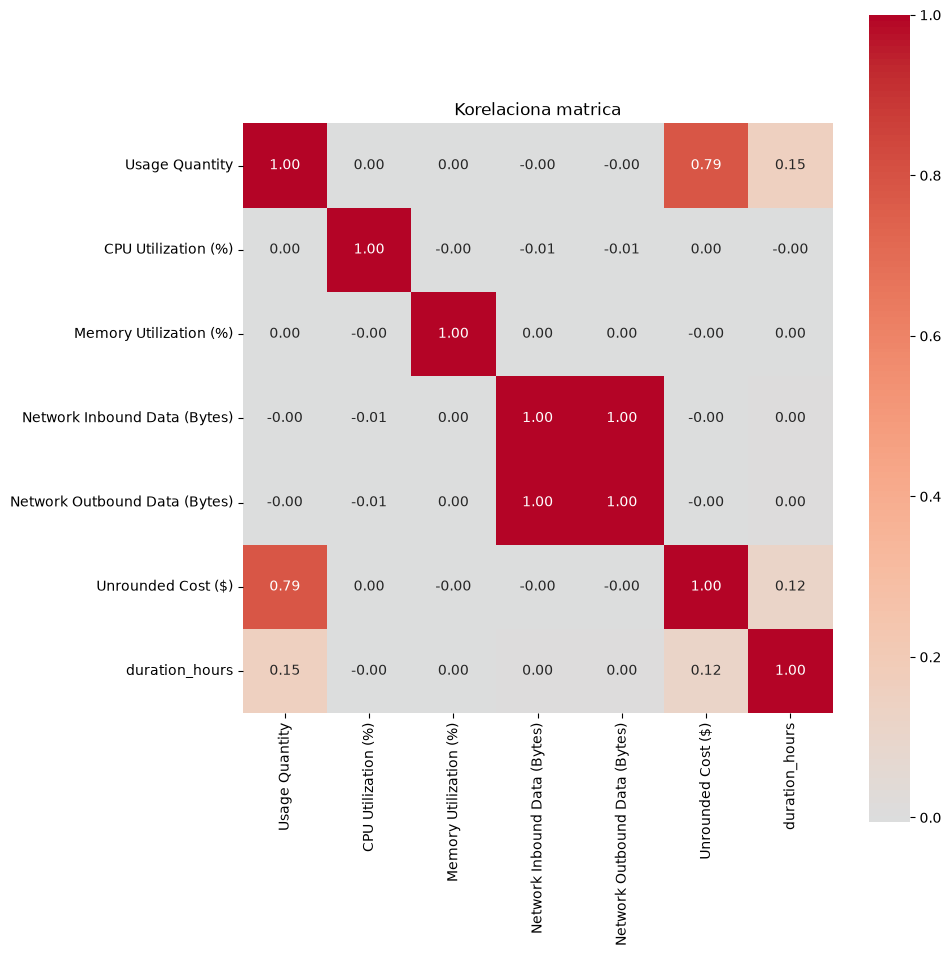

In [485]:
plot_correlation_heatmap(df,num_cols)

In [529]:
#df.drop(columns=['Usage Quantity','Network Inbound Data (Bytes)'], inplace=True)
#num_cols.remove('Usage Quantity')
df.drop(columns=['Network Inbound Data (Bytes)'], inplace=True)
num_cols.remove('Network Inbound Data (Bytes)')

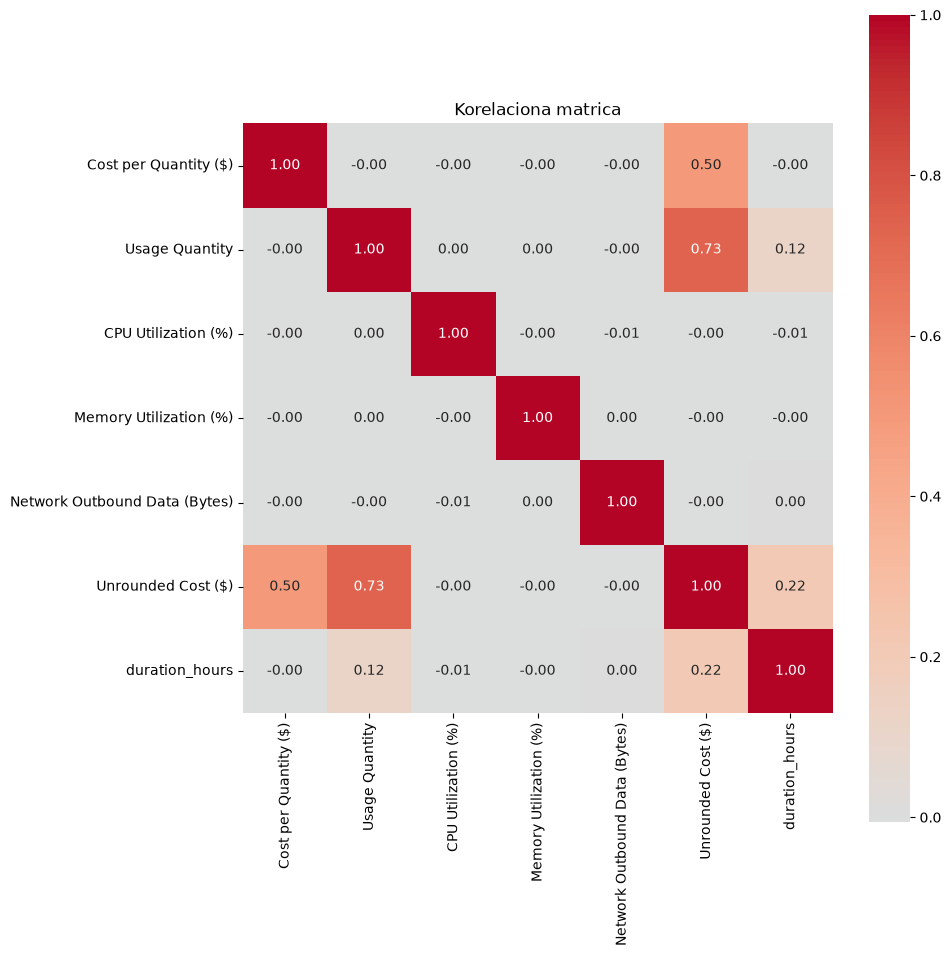

In [544]:
plot_correlation_heatmap(df,num_cols)

### Testiranje simetricnosti raspodela

Kako bismo omogucili skaliranje promenljivi i efikasni backpropagation, potrebno je testirati simetricnost raspodela promenljvi i transformisati promenljive sa asimetricnom raspodelom

In [530]:
import numpy as np
def plot_num_cols(df,columns,bins=40):
    n = len(columns)
    ncols = 3
    nrows = int(np.ceil(n/ncols))

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize= (6 * ncols, 6 * nrows))
    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(columns):
        data = df[col].dropna()
        label = col
        axes[i].hist(data, bins=bins,color='blue',edgecolor='black', alpha=0.8)
        axes[i].set_title(label)
        axes[i].set_xlabel(label)
        axes[i].set_ylabel("broj opservacija")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

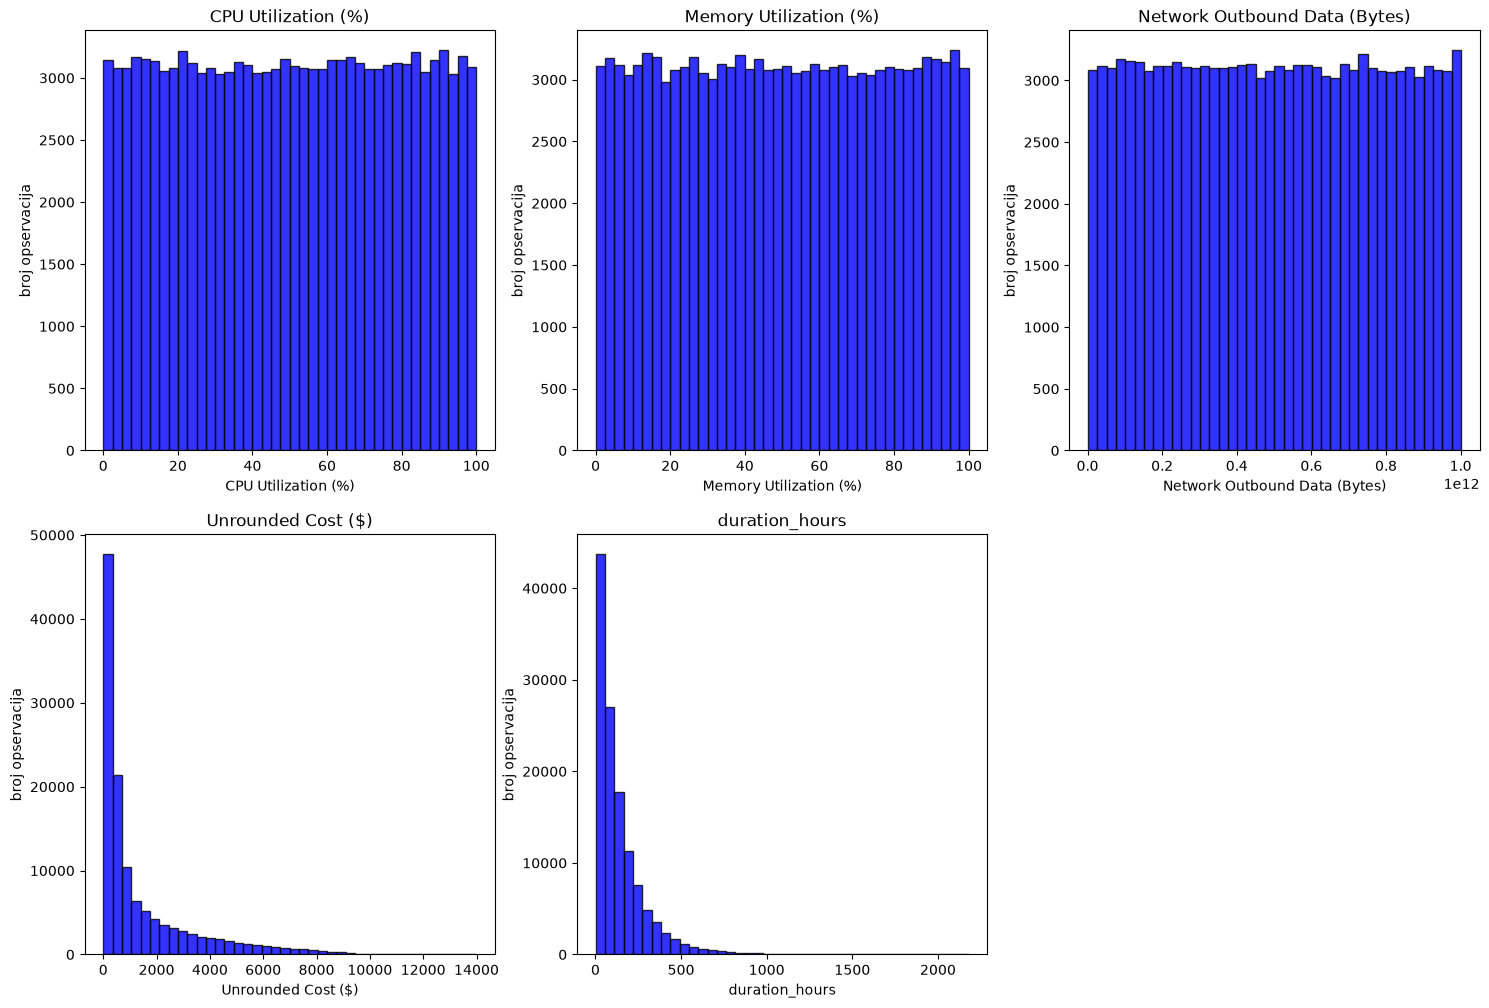

In [488]:
plot_num_cols(df,num_cols)

Takodje cemo uraditi test asimetricnosti kako bismo imali dodatnu potvrdu o asimetricnosti

Na osnovu datih grafikona raspodela može se zaključiti da sumarne metrike imaju raspodelu asimetricnu udesno. Primenicemo logaritamsku tranformaciju kako bismo korigovali ove raspodele

In [531]:
from scipy.stats import skew
for col in num_cols:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

Cost per Quantity ($): skew = 0.001
Usage Quantity: skew = 1.022
CPU Utilization (%): skew = -0.004
Memory Utilization (%): skew = 0.002
Network Outbound Data (Bytes): skew = 0.005
Unrounded Cost ($): skew = 1.875
duration_hours: skew = 2.708


In [532]:
df['Unrounded Cost ($)'] = np.log1p(df['Unrounded Cost ($)'])
df['duration_hours'] = np.log1p(df['duration_hours'])

### Graficki prikaz raspodela transformisanih kolona

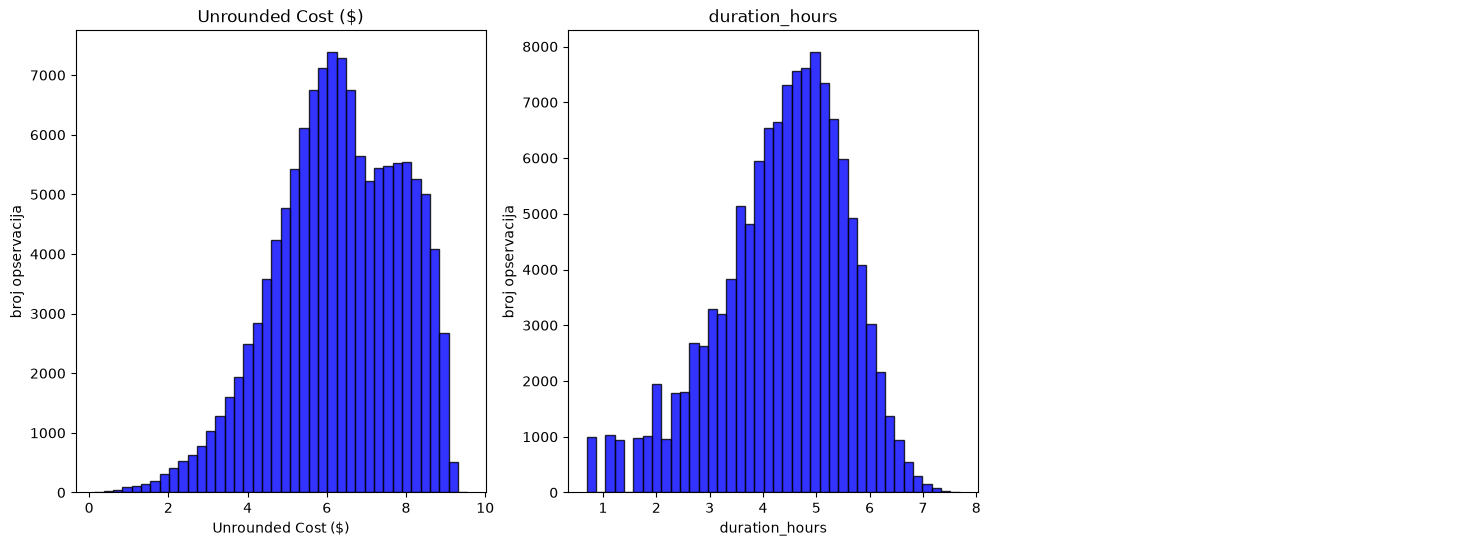

In [491]:
plot_num_cols(df,['Unrounded Cost ($)','duration_hours'])

Sada sumarne skale teze simetricnim raspodelama

In [492]:
for col in ['Unrounded Cost ($)','duration_hours']:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.3f}")

Unrounded Cost ($): skew = -0.394
duration_hours: skew = -0.596


Poslednje sto moramo da uradimo je konvertujemo numericke promenljive service i region u numericke, to cemo postici one-hot encoding-om

In [533]:
def one_hot_encode_col(dataframe, column):
    ohe = pd.get_dummies(dataframe[column], dtype=int)
    df_res = pd.concat([dataframe.drop(columns=column),ohe], axis=1)
    return df_res

In [534]:
df = one_hot_encode_col(df,'Service Name')
df = one_hot_encode_col(df,'Region / Zone')

In [495]:
df.sample(n = 10, random_state = 17)

,CPU Utilization (%),Memory Utilization (%),Network Outbound Data (Bytes),Unrounded Cost ($),duration_hours,App Engine,Artifact Registry,BigQuery,Cloud Armor,Cloud Build,...,Cloud Tasks,Compute Engine,Dialogflow,Secret Manager,asia-east1,asia-south1,europe-west1,us-central1,us-east1,us-west1
89924,9.17,89.07,1.306690e+11,7.864553,5.541264,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
57738,9.43,11.88,6.157440e+11,5.042909,5.342334,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
62271,40.11,28.23,7.254920e+11,6.861472,5.181784,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
98228,18.21,61.31,5.935249e+10,6.683426,4.543295,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
33495,77.47,62.08,7.896220e+11,2.959359,1.098612,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
850,5.18,37.36,9.005960e+11,5.582257,4.624973,1,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
25974,60.76,87.86,5.518410e+11,5.694924,6.161207,0,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
109838,88.95,74.52,6.426880e+11,7.712348,5.398163,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
64138,22.84,14.71,5.757210e+11,6.223537,5.332719,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
76491,69.66,92.95,2.719520e+11,5.721501,4.276666,1,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0


In [496]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 124275 entries, 0 to 124274
Data columns (total 34 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   CPU Utilization (%)            124275 non-null  float64
 1   Memory Utilization (%)         124275 non-null  float64
 2   Network Outbound Data (Bytes)  124275 non-null  float64
 3   Unrounded Cost ($)             124275 non-null  float64
 4   duration_hours                 124275 non-null  float64
 5   App Engine                     124275 non-null  int64  
 6   Artifact Registry              124275 non-null  int64  
 7   BigQuery                       124275 non-null  int64  
 8   Cloud Armor                    124275 non-null  int64  
 9   Cloud Build                    124275 non-null  int64  
 10  Cloud CDN                      124275 non-null  int64  
 11  Cloud Dataflow                 124275 non-null  int64  
 12  Cloud Dataproc                 124275 non

### Skaliranje i podela podataka

Podatke delimo na trening, validacioni i test skup, a zatim standardizujemo numeričke vrednosti. Skaliranje je ključno jer izjednačava opsege svih obeležja, što omogućava stabilan i brz rad gradijentnog spusta. Podela na dva zasebna skupa van treninga je neophodna da bi se izbeglo curenje informacija: validacioni skup se koristi tokom razvoja za podešavanje hiperparametara i sprečavanje overfittinga, dok test skup ostaje netaknut do samog kraja kako bi pružio potpuno objektivnu procenu tačnosti modela na novim podacima.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

target_col = 'Unrounded Cost ($)'
X = df.drop(columns=[target_col])
y = df[target_col].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

cols_to_scale = ['Cost per Quantity ($)','Usage Quantity','CPU Utilization (%)', 'Memory Utilization (%)', 'Network Outbound Data (Bytes)', 'duration_hours']
preprocessor = ColumnTransformer(
    transformers=[('num', StandardScaler(), cols_to_scale)],
    remainder='passthrough'
)

X_train = preprocessor.fit_transform(X_train).astype(np.float32)
X_val = preprocessor.transform(X_val).astype(np.float32)
X_test = preprocessor.transform(X_test).astype(np.float32)

train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(y_train.astype(np.float32)))
val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val.astype(np.float32)))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(y_test.astype(np.float32)))

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

### Pomoćne funkcije za evaluaciju i treniranje modela

Funkcija za treniranje neuronske mreže u kojoj early stopping. Nakon svake epohe evaluiramo nove parametre u odnosu na validacioni skup i ukoliko primetimo da se greška ne smanjuje tokom N uzastopnih epoha (definisano u patience), automatski prekidamo trening i pomoću metode deepcopy vraćamo model na stanje sa najboljim težinama koje smo zabeležili pre nego što je tačnost počela da opada.

In [ ]:

import copy

def train_model(
    model, 
    train_loader, 
    val_loader, 
    optimizer, 
    criterion, 
    epochs=50, 
    patience=8, 
    device="cpu"
):
    model.to(device)
    best_val_loss = float('inf')
    trigger_count = 0
    best_model_state = None
    
    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_train_loss = 0
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs.squeeze(), batch_y)
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        epoch_val_loss = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                epoch_val_loss += criterion(outputs.squeeze(), batch_y).item()
        
        avg_val_loss = epoch_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)
        
        print(f"Epoch {epoch+1} , Train Loss: {avg_train_loss:.4f} , Val Loss: {avg_val_loss:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            trigger_count = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            trigger_count += 1
            if trigger_count >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        
    return model, train_losses, val_losses

Funkcija za evaluaciju našeg regresionog modela, pomoću koje merimo koliko su tačna predviđanja neuronske mreže u poređenju sa stvarnim ciljnim vrednostima Računamo i ispisujemo ključne statističke metrike – poput srednje kvadratne greške (MSE/RMSE), srednje apsolutne greške (MAE), srednje apsolutne procentualne greške (MAPE) i koeficijenta determinacije ($R^2$). Bitno je primeniti inverznu transformaciju pomocu np.expm1, zbog logaritamske transformacije koju smo ranije uradili.

In [ ]:
import torch
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error

def evaluate_regression_model(model, data_loader):

    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch_X, batch_y in data_loader:
            outputs = model(batch_X)
            all_preds.append(outputs.view(-1).numpy())
            all_targets.append(batch_y.view(-1).numpy())

    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)

    all_preds_actual = np.expm1(all_preds)
    all_targets_actual = np.expm1(all_targets)

    mse = mean_squared_error(all_targets_actual, all_preds_actual)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(all_targets_actual, all_preds_actual)
    r2 = r2_score(all_targets_actual, all_preds_actual)
    mape = mean_absolute_percentage_error(all_targets_actual, all_preds_actual)

    metrics = {
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "MAPE": mape
    }

    for name, value in metrics.items():
        display_value = value * 100 if name == "MAPE" else value
        unit = "%" if name == "MAPE" else ""
        print(f"  {name:4}: {display_value:.4f}{unit}")

    return metrics

### Treniranje

Početni model predstavlja običnu feedforward mrežu sa dva skrivena sloja. Kao aktivacionu funkciju u skrivenim slojevima koristimo sigmoidnu funkciju, dok za optimizaciju primenjujemo stochastic gradient descent sa fiksnom stopom učenja i MSE kao funkcijom greške.

In [566]:
class CostPredictor1(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor1, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Sigmoid(),
            nn.Linear(64, 32),
            nn.Sigmoid(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model1 = CostPredictor1(X_train.shape[1])
criterion1 = nn.MSELoss()
optimizer1 = optim.SGD(model1.parameters(), lr=0.01)

In [569]:
model1, train_losses1, val_losses1 = train_model(model1, train_loader, val_loader, optimizer1, criterion1, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.3497 , Val Loss: 0.3485
Epoch 2 , Train Loss: 0.3174 , Val Loss: 0.3044
Epoch 3 , Train Loss: 0.2744 , Val Loss: 0.2574
Epoch 4 , Train Loss: 0.2291 , Val Loss: 0.2260
Epoch 5 , Train Loss: 0.1864 , Val Loss: 0.1694
Epoch 6 , Train Loss: 0.1498 , Val Loss: 0.1385
Epoch 7 , Train Loss: 0.1233 , Val Loss: 0.1197
Epoch 8 , Train Loss: 0.1053 , Val Loss: 0.1017
Epoch 9 , Train Loss: 0.0918 , Val Loss: 0.0936
Epoch 10 , Train Loss: 0.0813 , Val Loss: 0.0790
Epoch 11 , Train Loss: 0.0729 , Val Loss: 0.0722
Epoch 12 , Train Loss: 0.0659 , Val Loss: 0.0671
Epoch 13 , Train Loss: 0.0601 , Val Loss: 0.0595
Epoch 14 , Train Loss: 0.0552 , Val Loss: 0.0552
Epoch 15 , Train Loss: 0.0510 , Val Loss: 0.0530
Epoch 16 , Train Loss: 0.0471 , Val Loss: 0.0473
Epoch 17 , Train Loss: 0.0438 , Val Loss: 0.0440
Epoch 18 , Train Loss: 0.0410 , Val Loss: 0.0490
Epoch 19 , Train Loss: 0.0383 , Val Loss: 0.0397
Epoch 20 , Train Loss: 0.0360 , Val Loss: 0.0365
Epoch 21 , Train Loss: 0.0341

Vršimo evaluaciju obučenog modela na validacionom setu podataka.

In [625]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model1, val_loader)


Evaluating on Validation Set:
  MSE : 9207.3486
  RMSE: 95.9549
  MAE : 45.3677
  R2  : 0.9974
  MAPE: 6.8605%


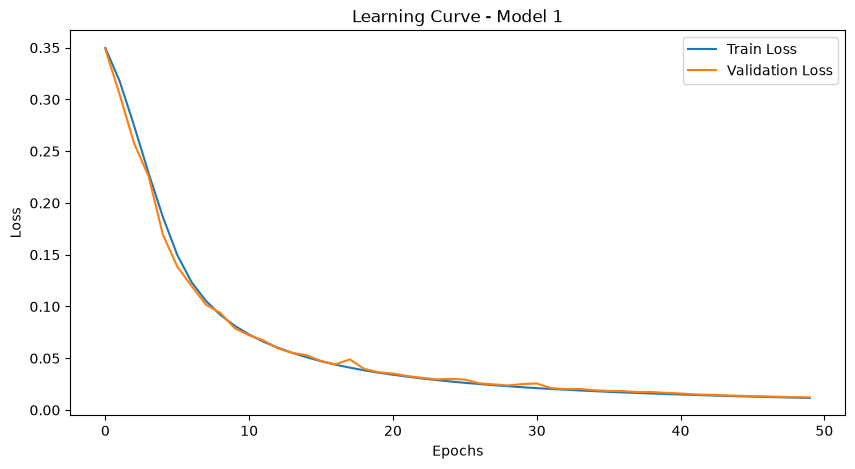

In [571]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses1, label='Train Loss')
plt.plot(val_losses1, label='Validation Loss')
plt.title('Learning Curve - Model 1')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Radi dalje optimizacije, testiramo model korišćenjem Huberove loss funkcije umesto MSE-a. Huber loss je robustnija alternativa jer kombinuje svojstva kvadratne greške za male vrednosti i apsolutne greške za velike, čineći model manje osetljivim na ekstremne vrednosti (outliers) u podacima o troškovima.

In [572]:
class CostPredictor2(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor2, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Sigmoid(),
            nn.Linear(64, 32),
            nn.Sigmoid(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model2 = CostPredictor2(X_train.shape[1])
criterion2 = nn.HuberLoss(delta=1)
optimizer2 = optim.SGD(model2.parameters(), lr=0.01)

In [573]:
model2, train_losses2, val_losses2 = train_model(model2, train_loader, val_loader, optimizer2, criterion2, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.6981 , Val Loss: 0.2350
Epoch 2 , Train Loss: 0.2032 , Val Loss: 0.1967
Epoch 3 , Train Loss: 0.1870 , Val Loss: 0.1860
Epoch 4 , Train Loss: 0.1787 , Val Loss: 0.1799
Epoch 5 , Train Loss: 0.1739 , Val Loss: 0.1762
Epoch 6 , Train Loss: 0.1704 , Val Loss: 0.1732
Epoch 7 , Train Loss: 0.1676 , Val Loss: 0.1707
Epoch 8 , Train Loss: 0.1649 , Val Loss: 0.1677
Epoch 9 , Train Loss: 0.1618 , Val Loss: 0.1644
Epoch 10 , Train Loss: 0.1583 , Val Loss: 0.1604
Epoch 11 , Train Loss: 0.1542 , Val Loss: 0.1566
Epoch 12 , Train Loss: 0.1493 , Val Loss: 0.1505
Epoch 13 , Train Loss: 0.1438 , Val Loss: 0.1447
Epoch 14 , Train Loss: 0.1376 , Val Loss: 0.1381
Epoch 15 , Train Loss: 0.1310 , Val Loss: 0.1307
Epoch 16 , Train Loss: 0.1238 , Val Loss: 0.1232
Epoch 17 , Train Loss: 0.1161 , Val Loss: 0.1148
Epoch 18 , Train Loss: 0.1077 , Val Loss: 0.1062
Epoch 19 , Train Loss: 0.0984 , Val Loss: 0.0962
Epoch 20 , Train Loss: 0.0886 , Val Loss: 0.0862
Epoch 21 , Train Loss: 0.0794

In [624]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model2, val_loader)


Evaluating on Validation Set:
  MSE : 34531.6602
  RMSE: 185.8270
  MAE : 112.6241
  R2  : 0.9902
  MAPE: 17.2406%


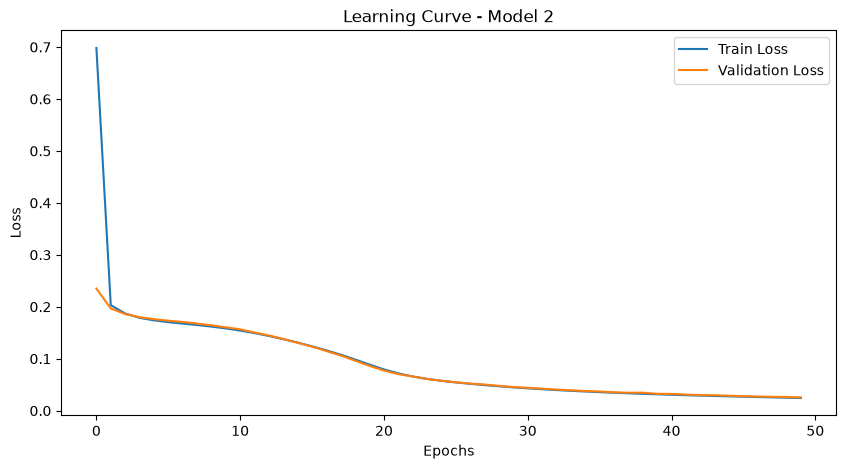

In [575]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses2, label='Train Loss')
plt.plot(val_losses2, label='Validation Loss')
plt.title('Learning Curve - Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

Analiza grafika učenja pokazala je da model sa Huber loss funkcijom konvergira sporije i postiže slabije rezultate u poređenju sa MSE, zbog čega zadržavamo MSE funkciju. U cilju daljeg poboljšanja performansi, zamenjujemo postojeće sigmoidne aktivacione funkcije sa ReLU funkcijom. Ona je popularna opcija u dubokom učenju jer između ostalog rešava problem vanishing gradient-a, čime se omogućava brže i stabilnije treniranje dubljih neuronskih mreža.

In [576]:
class CostPredictor3(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor3, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model3 = CostPredictor3(X_train.shape[1])
criterion3 = nn.MSELoss()
optimizer3 = optim.SGD(model3.parameters(), lr=0.01)



In [577]:
model3, train_losses3, val_losses3 = train_model(model3, train_loader, val_loader, optimizer3, criterion3, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.3630 , Val Loss: 0.0809
Epoch 2 , Train Loss: 0.0507 , Val Loss: 0.0340
Epoch 3 , Train Loss: 0.0276 , Val Loss: 0.0236
Epoch 4 , Train Loss: 0.0193 , Val Loss: 0.0182
Epoch 5 , Train Loss: 0.0146 , Val Loss: 0.0140
Epoch 6 , Train Loss: 0.0117 , Val Loss: 0.0102
Epoch 7 , Train Loss: 0.0096 , Val Loss: 0.0086
Epoch 8 , Train Loss: 0.0081 , Val Loss: 0.0078
Epoch 9 , Train Loss: 0.0070 , Val Loss: 0.0138
Epoch 10 , Train Loss: 0.0062 , Val Loss: 0.0058
Epoch 11 , Train Loss: 0.0054 , Val Loss: 0.0051
Epoch 12 , Train Loss: 0.0049 , Val Loss: 0.0057
Epoch 13 , Train Loss: 0.0045 , Val Loss: 0.0041
Epoch 14 , Train Loss: 0.0041 , Val Loss: 0.0038
Epoch 15 , Train Loss: 0.0038 , Val Loss: 0.0036
Epoch 16 , Train Loss: 0.0035 , Val Loss: 0.0041
Epoch 17 , Train Loss: 0.0033 , Val Loss: 0.0036
Epoch 18 , Train Loss: 0.0031 , Val Loss: 0.0035
Epoch 19 , Train Loss: 0.0029 , Val Loss: 0.0028
Epoch 20 , Train Loss: 0.0028 , Val Loss: 0.0031
Epoch 21 , Train Loss: 0.0027

In [623]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model3, val_loader)


Evaluating on Validation Set:
  MSE : 4370.7930
  RMSE: 66.1120
  MAE : 30.9417
  R2  : 0.9988
  MAPE: 2.6973%


ReLU arhitektura je postigla značajno bolje rezultate. Kao sledeći korak, testiramo model sa tanh (hiperbolički tangens) aktivacionom funkcijom. Iako tanh, za razliku od ReLU, nije otporna na problem zasićenja gradijenta, ona centrira izlaze oko nule, što u određenim slučajevima može dovesti do bržeg konvergiranja i stabilnije optimizacije težina.

In [628]:
class CostPredictor4(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor4, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model4 = CostPredictor4(X_train.shape[1])
criterion4 = nn.MSELoss()
optimizer4 = optim.SGD(model4.parameters(), lr=0.01)

In [629]:
model4, train_losses4, val_losses4 = train_model(model4, train_loader, val_loader, optimizer4, criterion4, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.3239 , Val Loss: 0.1119
Epoch 2 , Train Loss: 0.0801 , Val Loss: 0.0676
Epoch 3 , Train Loss: 0.0460 , Val Loss: 0.0440
Epoch 4 , Train Loss: 0.0290 , Val Loss: 0.0262
Epoch 5 , Train Loss: 0.0202 , Val Loss: 0.0172
Epoch 6 , Train Loss: 0.0151 , Val Loss: 0.0141
Epoch 7 , Train Loss: 0.0120 , Val Loss: 0.0119
Epoch 8 , Train Loss: 0.0100 , Val Loss: 0.0099
Epoch 9 , Train Loss: 0.0086 , Val Loss: 0.0081
Epoch 10 , Train Loss: 0.0075 , Val Loss: 0.0080
Epoch 11 , Train Loss: 0.0067 , Val Loss: 0.0062
Epoch 12 , Train Loss: 0.0061 , Val Loss: 0.0064
Epoch 13 , Train Loss: 0.0055 , Val Loss: 0.0054
Epoch 14 , Train Loss: 0.0050 , Val Loss: 0.0050
Epoch 15 , Train Loss: 0.0047 , Val Loss: 0.0045
Epoch 16 , Train Loss: 0.0043 , Val Loss: 0.0042
Epoch 17 , Train Loss: 0.0040 , Val Loss: 0.0039
Epoch 18 , Train Loss: 0.0038 , Val Loss: 0.0039
Epoch 19 , Train Loss: 0.0035 , Val Loss: 0.0034
Epoch 20 , Train Loss: 0.0033 , Val Loss: 0.0035
Epoch 21 , Train Loss: 0.0031

In [630]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model4, val_loader)


Evaluating on Validation Set:
  MSE : 873.7487
  RMSE: 29.5592
  MAE : 14.4375
  R2  : 0.9998
  MAPE: 2.0123%


Model sa tanh aktivacionim funkcijama dao je najbolje rezultate. Međutim, posmatranjem krive gubitka uočeno je osciliranje i preskakanje minimuma funkcije, što ukazuje na to da fiksni learning rate SGD optimizatora možda nije optimalan. Kao rešenje, prelazimo na Adam optimizator, koji primenjuje adaptivnu stopu učenja za svaki parametar posebno.

In [584]:
class CostPredictor5(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor5, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model5 = CostPredictor5(X_train.shape[1])
criterion5 = nn.MSELoss()
optimizer5 = optim.Adam(model5.parameters(), lr=0.001)

In [586]:
model5, train_losses5, val_losses5 = train_model(model5, train_loader, val_loader, optimizer5, criterion5, epochs=50, patience=8);

Epoch 1 , Train Loss: 1.0604 , Val Loss: 0.0439
Epoch 2 , Train Loss: 0.0215 , Val Loss: 0.0139
Epoch 3 , Train Loss: 0.0097 , Val Loss: 0.0100
Epoch 4 , Train Loss: 0.0070 , Val Loss: 0.0050
Epoch 5 , Train Loss: 0.0055 , Val Loss: 0.0058
Epoch 6 , Train Loss: 0.0048 , Val Loss: 0.0090
Epoch 7 , Train Loss: 0.0043 , Val Loss: 0.0028
Epoch 8 , Train Loss: 0.0039 , Val Loss: 0.0030
Epoch 9 , Train Loss: 0.0038 , Val Loss: 0.0040
Epoch 10 , Train Loss: 0.0035 , Val Loss: 0.0025
Epoch 11 , Train Loss: 0.0032 , Val Loss: 0.0015
Epoch 12 , Train Loss: 0.0031 , Val Loss: 0.0053
Epoch 13 , Train Loss: 0.0028 , Val Loss: 0.0062
Epoch 14 , Train Loss: 0.0028 , Val Loss: 0.0019
Epoch 15 , Train Loss: 0.0027 , Val Loss: 0.0018
Epoch 16 , Train Loss: 0.0023 , Val Loss: 0.0036
Epoch 17 , Train Loss: 0.0023 , Val Loss: 0.0013
Epoch 18 , Train Loss: 0.0024 , Val Loss: 0.0012
Epoch 19 , Train Loss: 0.0022 , Val Loss: 0.0018
Epoch 20 , Train Loss: 0.0020 , Val Loss: 0.0019
Epoch 21 , Train Loss: 0.0021

In [621]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model5, val_loader)


Evaluating on Validation Set:
  MSE : 3098.7822
  RMSE: 55.6667
  MAE : 23.6332
  R2  : 0.9991
  MAPE: 2.2255%


Eksperimentalna poređenja pokazala su da konfiguracija sa tanh aktivacijom i SGD optimizatorom (fiksni learning rate) trenutno daje najstabilnije i najpreciznije rezultate. Za svaki slučaj, povećali smo kapacitet mreže proširenjem skrivenog sloja na 128 neurona kako bismo omogućili modeliranje kompleksnijih zavisnosti. Inicijalno smo testirali i Dropout sloj radi regularizacije, međutim, on je uklonjen iz finalne arhitekture jer je dovodio do underfitting-a.

In [591]:
class CostPredictor6(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor6, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.Tanh(),
            #nn.Dropout(0.4),
            nn.Linear(128, 32),    
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)


model6 = CostPredictor6(X_train.shape[1])
criterion6 = nn.MSELoss()
optimizer6 = optim.Adam(model6.parameters(), lr=0.001)

In [592]:
model6, train_losses6, val_losses6 = train_model(model6, train_loader, val_loader, optimizer6, criterion6, epochs=50, patience=8);

Epoch 1 , Train Loss: 0.8598 , Val Loss: 0.0345
Epoch 2 , Train Loss: 0.0168 , Val Loss: 0.0089
Epoch 3 , Train Loss: 0.0087 , Val Loss: 0.0081
Epoch 4 , Train Loss: 0.0071 , Val Loss: 0.0092
Epoch 5 , Train Loss: 0.0064 , Val Loss: 0.0071
Epoch 6 , Train Loss: 0.0053 , Val Loss: 0.0032
Epoch 7 , Train Loss: 0.0048 , Val Loss: 0.0032
Epoch 8 , Train Loss: 0.0045 , Val Loss: 0.0034
Epoch 9 , Train Loss: 0.0041 , Val Loss: 0.0038
Epoch 10 , Train Loss: 0.0038 , Val Loss: 0.0036
Epoch 11 , Train Loss: 0.0037 , Val Loss: 0.0018
Epoch 12 , Train Loss: 0.0034 , Val Loss: 0.0022
Epoch 13 , Train Loss: 0.0034 , Val Loss: 0.0037
Epoch 14 , Train Loss: 0.0028 , Val Loss: 0.0025
Epoch 15 , Train Loss: 0.0031 , Val Loss: 0.0019
Epoch 16 , Train Loss: 0.0029 , Val Loss: 0.0028
Epoch 17 , Train Loss: 0.0027 , Val Loss: 0.0041
Epoch 18 , Train Loss: 0.0027 , Val Loss: 0.0024
Epoch 19 , Train Loss: 0.0024 , Val Loss: 0.0024
Early stopping triggered at epoch 19


In [620]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model6, val_loader)


Evaluating on Validation Set:
  MSE : 2475.3503
  RMSE: 49.7529
  MAE : 25.7511
  R2  : 0.9993
  MAPE: 2.7190%


Model 4 (tanh + SGD) je i dalje najefikasniji u dosadašnjim eksperimentima. U cilju daljeg finog podešavanja i postizanja boljih performansi, uveli smo ReduceLROnPlateau scheduler koji dinamički menja learning rate kada validacioni loss stagnira. Pored toga, povećali smo ukupan broj epoha, što modelu omogućava duži proces konvergencije.

In [613]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

class CostPredictor7(nn.Module):
    def __init__(self, input_size):
        super(CostPredictor7, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.Tanh(),
            nn.Linear(64, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

model7 = CostPredictor7(X_train.shape[1])
criterion7 = nn.MSELoss()
optimizer7 = optim.SGD(model7.parameters(), lr=0.01)
scheduler7 = ReduceLROnPlateau(optimizer7, mode='min', factor=0.1, patience=5, threshold=0.01, 
    threshold_mode='rel')


In [614]:
device = "cpu"

model7.to(device)
best_val_loss = float('inf')
trigger_count = 0
best_model_state = None
 
train_losses = []
val_losses = []

epochs = 150
patience = 10

for epoch in range(epochs):
    model7.train()
    epoch_train_loss = 0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
         
        optimizer7.zero_grad()
        outputs = model7(batch_X)
        loss = criterion7(outputs.squeeze(), batch_y)
        loss.backward()
        optimizer7.step()
        epoch_train_loss += loss.item()
     
    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
     
    model7.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            outputs = model7(batch_X)
            epoch_val_loss += criterion7(outputs.squeeze(), batch_y).item()
     
    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
     
    print(f"Epoch {epoch+1} , Train Loss: {avg_train_loss:.4f} , Val Loss: {avg_val_loss:.4f} , LR: {optimizer7.param_groups[0]['lr']:.6f}")
    scheduler7.step(avg_val_loss)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        trigger_count = 0
        best_model_state = copy.deepcopy(model7.state_dict())
    else:
        trigger_count += 1
        if trigger_count >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

if best_model_state is not None:
    model7.load_state_dict(best_model_state)

Epoch 1 , Train Loss: 0.3171 , Val Loss: 0.0928 , LR: 0.010000
Epoch 2 , Train Loss: 0.0645 , Val Loss: 0.0458 , LR: 0.010000
Epoch 3 , Train Loss: 0.0347 , Val Loss: 0.0272 , LR: 0.010000
Epoch 4 , Train Loss: 0.0216 , Val Loss: 0.0180 , LR: 0.010000
Epoch 5 , Train Loss: 0.0153 , Val Loss: 0.0136 , LR: 0.010000
Epoch 6 , Train Loss: 0.0120 , Val Loss: 0.0110 , LR: 0.010000
Epoch 7 , Train Loss: 0.0100 , Val Loss: 0.0091 , LR: 0.010000
Epoch 8 , Train Loss: 0.0086 , Val Loss: 0.0079 , LR: 0.010000
Epoch 9 , Train Loss: 0.0075 , Val Loss: 0.0069 , LR: 0.010000
Epoch 10 , Train Loss: 0.0067 , Val Loss: 0.0062 , LR: 0.010000
Epoch 11 , Train Loss: 0.0060 , Val Loss: 0.0056 , LR: 0.010000
Epoch 12 , Train Loss: 0.0055 , Val Loss: 0.0052 , LR: 0.010000
Epoch 13 , Train Loss: 0.0050 , Val Loss: 0.0048 , LR: 0.010000
Epoch 14 , Train Loss: 0.0047 , Val Loss: 0.0046 , LR: 0.010000
Epoch 15 , Train Loss: 0.0043 , Val Loss: 0.0048 , LR: 0.010000
Epoch 16 , Train Loss: 0.0040 , Val Loss: 0.0038 

In [619]:
print("\nEvaluating on Validation Set:")
val_results = evaluate_regression_model(model7, val_loader)


Evaluating on Validation Set:
  MSE : 736.3701
  RMSE: 27.1361
  MAE : 13.5053
  R2  : 0.9998
  MAPE: 1.7710%


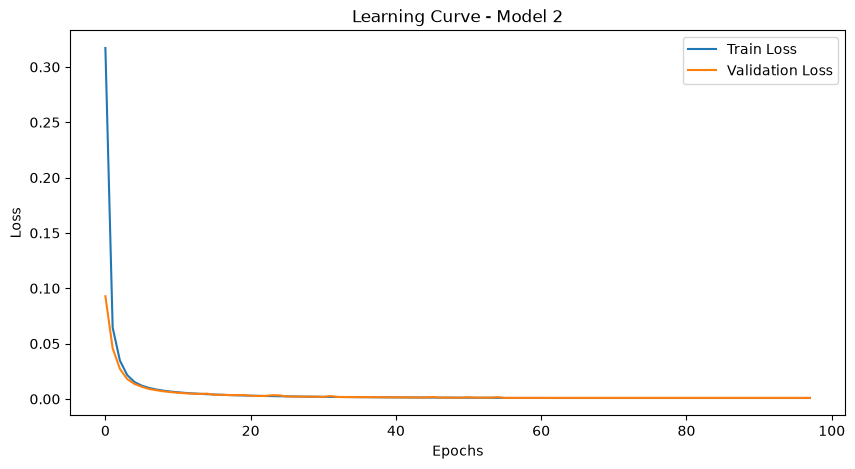

In [616]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Learning Curve - Model 2')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

### Evaluacija

Za konačnu procenu performansi koristimo test set koji do sada nismo koristili u procesu treniranja niti validacije. Ovim osiguravamo nepristrasnu procenu sposobnosti modela da generalizuje na potpuno nove podatke, eliminišući rizik od „data leakage“ i potvrđujući njegovu stvarnu primenljivost u produkcionom okruženju.

In [617]:
print("\nEvaluating on Test Set:")
val_results = evaluate_regression_model(model7, test_loader)


Evaluating on Test Set:
  MSE : 970.9288
  RMSE: 31.1597
  MAE : 13.7638
  R2  : 0.9997
  MAPE: 1.7178%


Konačni rezultati evaluacije na testnom setu potvrđuju odlične performanse modela. R² skor od 0.9997 ukazuje na gotovo savršeno prilagođavanje podacima, dok MAPE od 1.7178% potvrđuje visoku preciznost. Mala razlika između RMSE i MAE metrika dodatno ukazuje na robusnost modela i odsustvo značajnog uticaja ekstremnih vrednosti (outliers), što ovaj model čini izuzetno pouzdanim alatom za precizno predviđanje budućih troškova.